# 20260820 - Introduction

## CSCI 5576/4576 - High Performance Scientific Computing

## Who am I?
- Postdoctoral Researcher in Aerospace Engineering
    - Recieved PhD at CU Boulder, MS and BS at Clemson University (South Carolina)
    - Probably soon to be researcher at NCAR
- I'm an engineer first, computer scientist second, and mathmatician third
    - Just don't ask me how rockets, planes, or satelites work
- Research Focus areas:
    - Computational Fluid Dynamics
    - PDE discretizations
    - Large scale fluid simulations
   

- Primary developer of HONEE (High-Order Navier-stokes Equation Evaluator) CFD software
    - Developed during my PhD
    - Scalable to 24,000 GPUs, problem sizes >10 billion DoFs
- HPC user for nearly a decade now
    - Started when I was on Clemson's Formula SAE team

- Outside of work, really enjoy climbing, hiking, skiing, biking, etc.
   - Go on a hike; I didn't for 2 years out here and regret it.

<div>
    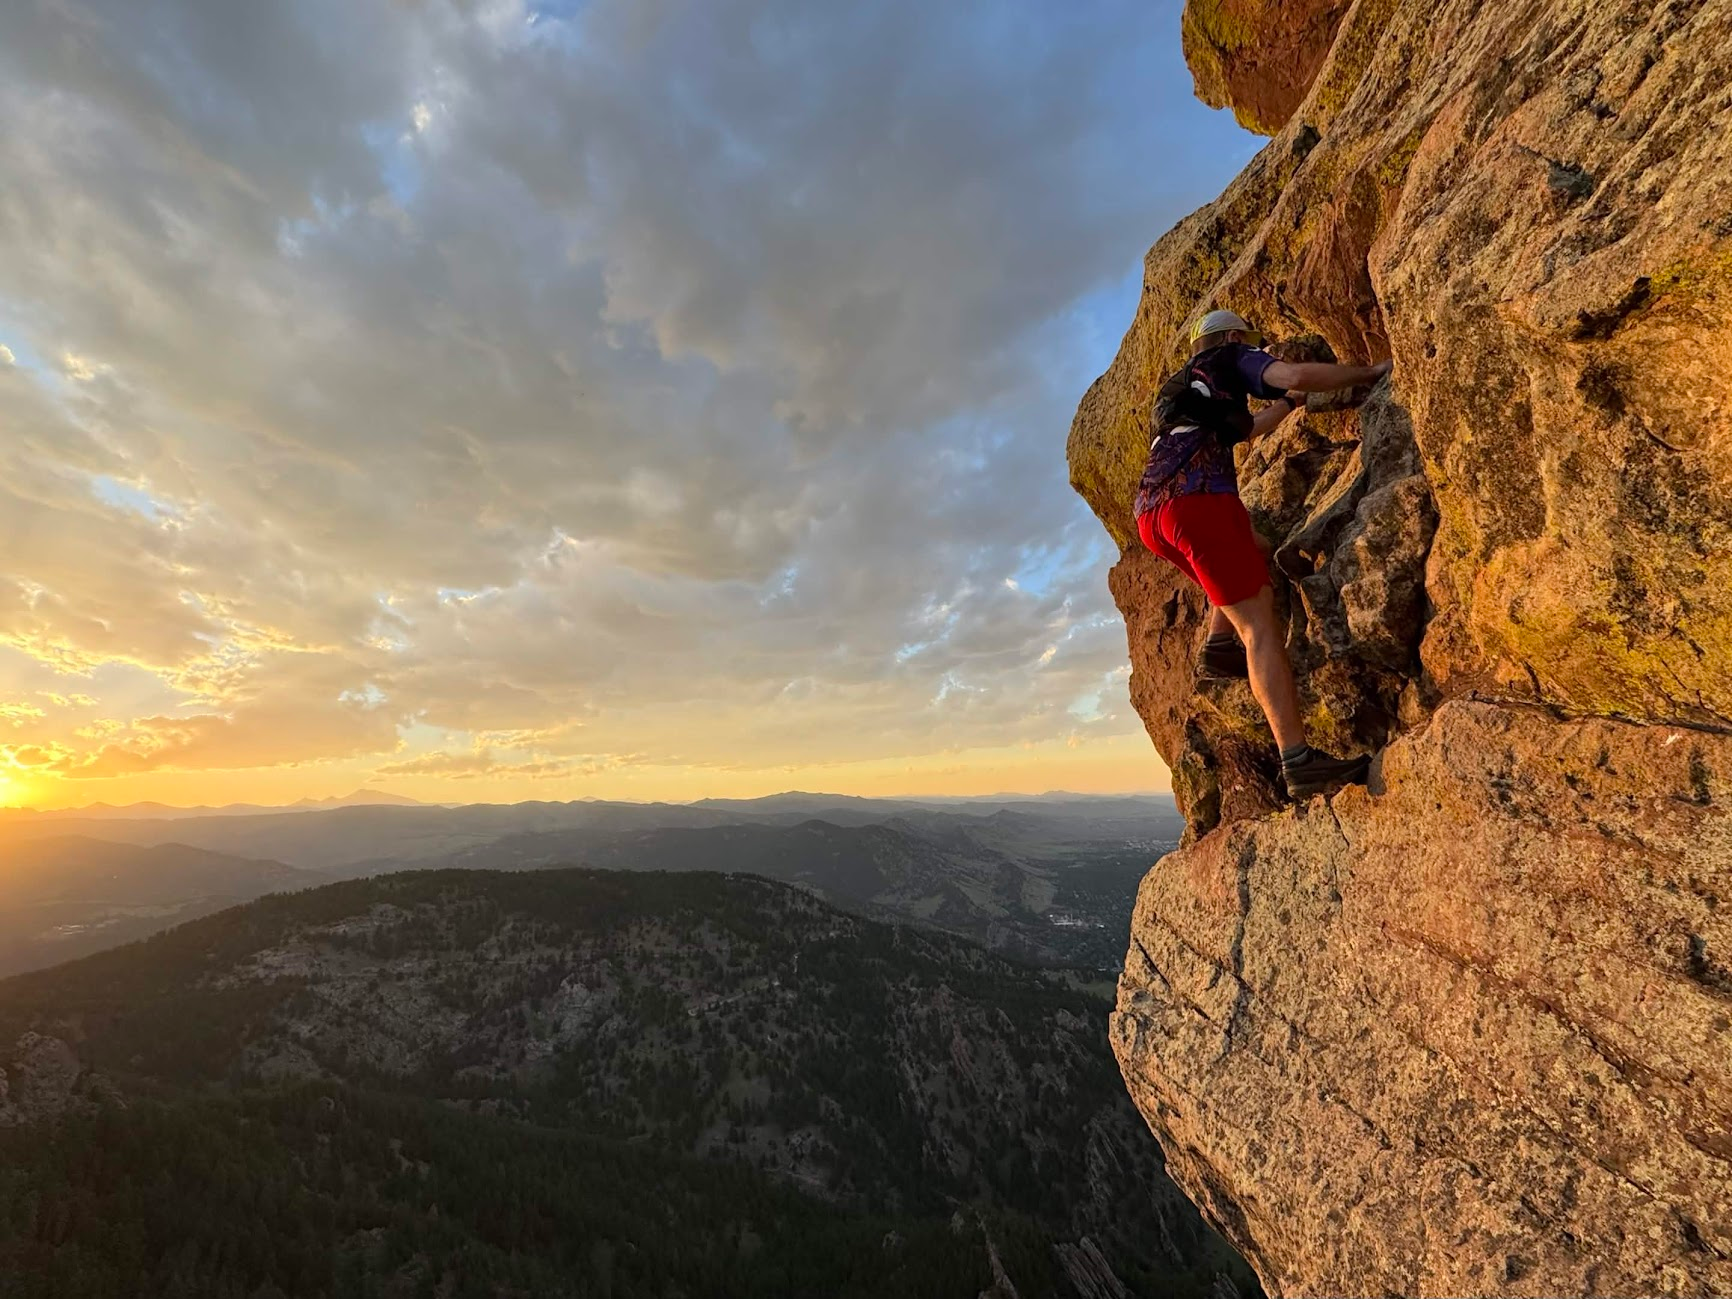
</div>

## Who is this class for?

- Anybody who plans on writing high-performance computing code for science purposes
    - Be that modifying an existing code or creating one from scratch
- No previous HPC experience required, but previous coding experience necessary
    - We'll be coding primarily in C

## What does this course cover?

- Hardware architecture for performance
- Parallel programming using OpenMP and MPI
- Basic parallel algorithms and performance modeling
- GPU Programming
- Verification and Validation of scientific codes
- Usage of HPC resources
- Some application examples

## Syllabus, Ungrading, and Assignments

- Course website: [cu-hpsc-fall-2026.github.io](https://cu-hpsc-fall-2026.github.io/)
- Syllabus
- Zulip
- Assignments
- Labs

## How does a computer work?

### Von Neumann Architecture

![image](../img/Von_Neumann_Architecture.svg)

Two core components:
- CPU - Logic and arithmetic
- Memory - Stores "intermediate" data

A *program* is a *series of instructions* done by the CPU.
Instructions (nearly always) are one of thee basic operations:
- Move data around in memory
- Perform computations on data
- Jump between different places in a program

Instructions are "executed" once per-clock cycle

### Registers

Data can only be operated on in **registers**: a handful of slots in the CPU that stores data

<div class="alert alert-block alert-info">
<b>Analogy:</b> 
If you're working out a math problem on paper:
    
| Computer | Hand-worked Math |
| --- | --- |
| Registers | Short-term memory |
| RAM | Paper |
</div>

For example, to compute `(6 + 9) * 4` you might do
- Load 6 and 9 into short-term memory
- Add them to get 15 (stored in short-term memory)
- Write result on a paper as `(15) * 4`
- Load 15 and 4 into short-term memory
- Multiply to get 60
- Write `= 60` on paper

Competent humans will obviously not write down every intermediate step, but computers must take every step literally.

### Simple Example of CPU: Fibonacci Sequence

#### A Simple CPU set of instructions

| Name | Args | Description |
| ---- | ---- | ------ |
| `load` | `src dest` | Load data from source memory address to the destination register |
| `store` | `src dest` | Store data from source register to the destination memory address |
| `add`  | `x y` | Add x to y, result stored in x, `x += y` |
| `inc` | `x` | Add 1 to x (so we don't have to have a register with 1 in it) |
| `dec` | `x` | Subtract 1 to x (so we don't have to have a register with 1 in it) |
| `jump_ne` | `x y dest` | Jump execution to the set location if x not equal to y |
| `return` | None | Ends the program |

| Notation | Meaning |
| ---- | ---- |
| `#3`  | Literal number 3, constant value|
| `@a`  | Register `a` |
| `&0` | Memory address 0 |
| `6` | Instruction number 6 |

#### Fibonacci Sequence

$$f_0 = 1$$
$$f_1 = 1$$
$$f_i = f_{i-1} + f_{i-2}, \quad \forall i \in [2,\infty)$$

$$[1, 1, 2, 3, 5, 8, \dots]$$

#### A Program for Computing the Fibonacci Sequence
A program for computing the Fibonacci sequence using the 6 instructions described above.
We use the registers in the following manner:

- `@n` sets how many fibonacci numbers we want to set (we compute `@n +1` Fibonacci numbers
- `@a` and `@b` are the registers are used to compute the next Fibonacci number
- `@d` is used as a "pointer", which determines where in memory to `load`/`store` data from

```assembly
0: load #3 @n            # Load number of Fibonacci numbers to compute into @n
1: store #1 &0           # Initialize the first Fibonacci number into address &0
2: store #1 &1           # Initialize the second Fibonacci number into address &0
3: load &0 @a            # Load the first Fibonacci number into @a
4: load &1 @b            # Load the second Fibonacci number into @b
5: load #1 @d            # Initialize @d to point at the largest computed Fibonacci number (the second, stored at address &1)
## Main loop starts here
6:  add @a @b            # Compute the @d + 1 Fibonacci number (result is stored in @a)
7:  inc @d               # Shift @d to point at next empty memory slot
8:  store @a @d          # Store @a (our newly computed Fibonacci number) into the empty memory slot
9:  dec @d               # Shift @d to point to the previous largest Fibonacci number
10: load @d @b           # Place the previous largest Fibonacci number into @b
11: inc @d               # Reset @d to point at the largest computed Fibonacci number in memory
12: jump_ne @d @n 6      # If the address @d is not equal to @n, then we continue looping. Otherwise, the program stops (there are no more instructions).
13: return               # End the program if the previous jump is not performed
```

#### Fibonacci Walkthrough

Below table goes through each instruction sequentially, showing how the registers and memory change with each instruction.

**Initialization:**

| Instructions               | \| | @d | @a | @b | @n | \| | &0 | &1 | &2 | &3 |
| ---                        | -- | ---| -- | -- | -- | -- | -- | -- | -- | -- |
| `0: load #3 @n`            |    | -  | -  | -  | 3  |    | -  | -  | -  | -  |
| `1: store #1 &0`           |    | -  | -  | -  | 3  |    | 1  | -  | -  | -  |
| `2: store #1 &1`           |    | -  | -  | -  | 3  |    | 1  | 1  | -  | -  |
| `3: load &0 @a`            |    | -  | 1  | -  | 3  |    | 1  | 1  | -  | -  |
| `4: load &1 @b`            |    | -  | 1  | 1  | 3  |    | 1  | 1  | -  | -  |
| `5: load #1 @d`            |    | 1  | 1  | 1  | 3  |    | 1  | 1  | -  | -  |

**Main Loop: first iteration**

| Instructions               | \| | @d | @a | @b | @n | \| | &0 | &1 | &2 | &3 |
| ---                        | -- | ---| -- | -- | -- | -- | -- | -- | -- | -- |
| `6:  add  @a @b`           |    | 1  | 2  | 1  | 3  |    | 1  | 1  | -  | -  |
| `7:  inc @d`               |    | 2  | 2  | 1  | 3  |    | 1  | 1  | -  | -  |
| `8:  store @a @d`          |    | 2  | 2  | 1  | 3  |    | 1  | 1  | 2  | -  |
| `9:  dec @d`               |    | 1  | 2  | 1  | 3  |    | 1  | 1  | 2  | -  |
| `10: load @d @b`           |    | 1  | 2  | 1  | 3  |    | 1  | 1  | 2  | -  |
| `11: inc @d`               |    | 2  | 2  | 1  | 3  |    | 1  | 1  | 2  | -  |
| `12: jump_ne @d @n 6`      |    | 2  | 2  | 1  | 3  |    | 1  | 1  | 2  | -  |

**Main Loop: second iteration**

| Instructions               | \| | @d | @a | @b | @n | \| | &0 | &1 | &2 | &3 |
| ---                        | -- | ---| -- | -- | -- | -- | -- | -- | -- | -- |
| `6:  add  @a @b`           |    | 2  | 3  | 1  | 3  |    | 1  | 1  | 2  | -  |
| `7:  inc @d`               |    | 3  | 3  | 1  | 3  |    | 1  | 1  | 2  | -  |
| `8:  store @a @d`          |    | 3  | 3  | 1  | 3  |    | 1  | 1  | 2  | 3  |
| `9:  dec @d`               |    | 2  | 3  | 1  | 3  |    | 1  | 1  | 2  | 3  |
| `10: load @d @b`           |    | 2  | 3  | 2  | 3  |    | 1  | 1  | 2  | 3  |
| `11: inc @d`               |    | 3  | 3  | 2  | 3  |    | 1  | 1  | 2  | 3  |
| `12: jump_ne @d @n 6`      |    | 3  | 3  | 2  | 3  |    | 1  | 1  | 2  | 3  |
| `13: return`               |    | 3  | 3  | 2  | 3  |    | 1  | 1  | 2  | 3  |

### Mapping real code to CPU instructions

The above is interesting, but I can almost guarantee that nobody in this class will be hand writing up assembly (though *reading* assembly is a very useful skill).
Instead, we program in some higher level language and then a compiler translates this down to assembly and machine code.

Being able to generally map between high level code and the actual instructions run by the CPU is critical to understanding performance of your code and how to make it better.

So here's an example: we take two arrays, `in_1` and `in_2`, and do a vector addition into an output array `out`.

```c
double in_1[1000], in_2[1000], out[1000];

void foo() {
  for (int i=0; i<1000; i++) {
    out[i] = in_1[i] + in_2[i];
  }
}
```

- All three arrays are stored in RAM.
- We know that the addition instruction can only be performed with data in registers, so we need to copy our input data.
- The result of that computation is also stored in registers and must be copied back into memory

So let's look at a modified copy of the function, but we explicitly put the movement of data into/out of registers:

```
void foo_registers() {
  double @a, @b;
  int    @c = 0; // This is `i`, our loop index
  for (; @c<1000; @c++) {
    @a  = in_1[@c];
    @b  = in_2[@c];
    @a += @b;
    out[@c] = @a;
  }
}
```

What would this code look like in our made-up CPU instruction sets?
For ease of understanding, let's adopt some additional notatation (which is very common in actually assembly).
We can index memory by specifying an address and incrementing the pointer in the same line. So

```
load @c[@d] @a
```

would take the memory address in `@c`, increment it by the value in `@d`, and load it into register `@a`.
If `@c = 5` and `@d = 2`, then we would get data from memory address `7`.

<div class="alert alert-block alert-info">
<b>Note:</b> 
This is actually where the symantics of index-by-0 comes from. We store the first memory address in some pointer (`@c`) and index into it by adding an offset (`@d`). So to access the first element in the array, the offset must be `0`, hence the index of the first.

You can also make an argument for index-by-0 being better than index-by-1 as 0 is the additive identity (and makes some indexing operations easier), but the root cause for it's popularity is the mechanism that hardware uses to access the data.
</div>

Using this new notation, the assembly for the vector addition becomes

```assembly
0: load #0 @x       # Load address of in_1 array into @x
1: load #10 @y      # Load address of in_2 array into @y
2: load #20 @z      # Load address of out array into @z
3: load #0 @d       # Set loop index to zero
## Main loop start  
4: load @x[@d] @a   # Load `@d`th element of in_1 into @a
5: load @y[@d] @b   # Load `@d`th element of in_2 into @b
6: add  @a @b       # Add the elements together
7: store @a @z[@d]  # Store the addition result into the `@d`th element of out array
8: inc @d           # Increment our loop index
9: jump_ne @d #10 4 # Loop if we haven't reached the end of the arrays
10: return
```

#### Actual Assembly

How does our made up CPU instructions compare to the actual code generated by a compiler?

https://godbolt.org/z/xsb9K11KP

```assembly
"foo":
        mov     eax, 0
.L2:
        movsd   xmm0, QWORD PTR "a"[rax]
        addsd   xmm0, QWORD PTR "b"[rax]
        movsd   QWORD PTR "c"[rax], xmm0
        add     rax, 8
        cmp     rax, 8000
        jne     .L2
        ret
"c":
        .zero   8000
"b":
        .zero   8000
"a":
        .zero   8000
```

For x86, a few minor differences:
- Registers are named differently, (e.g. `eax`, `xmm0`, `rax`, etc)
- x86 allows for certain arguments to directly reference memory rather than registers
    -  This simply hides the extra memory transfer to an un-named register; there is still a move operation required, it is just hidden
- We increment by 8 rather than by 1 each loop (`rax` is always multiples of 8)